In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# Top 10,000 frequently used words
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Samples : 25000
Testing Samples : 25000


In [3]:
max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post'
)

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


In [4]:
model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')

])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=5,

    batch_size=64,

    callbacks=[early_stop]

)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 255ms/step - accuracy: 0.5523 - loss: 0.6732 - val_accuracy: 0.6176 - val_loss: 0.6036
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 252ms/step - accuracy: 0.6472 - loss: 0.5702 - val_accuracy: 0.6418 - val_loss: 0.5832
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 253ms/step - accuracy: 0.7485 - loss: 0.4761 - val_accuracy: 0.8326 - val_loss: 0.4210
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 251ms/step - accuracy: 0.8749 - loss: 0.3254 - val_accuracy: 0.8506 - val_loss: 0.3889
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 251ms/step - accuracy: 0.9122 - loss: 0.2335 - val_accuracy: 0.8702 - val_loss: 0.3665


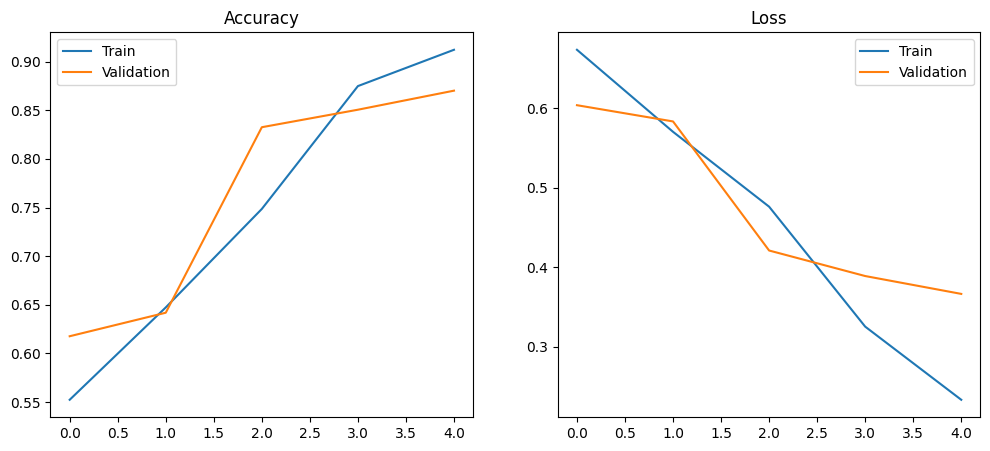

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train")
plt.plot(history.history['val_loss'], label="Validation")
plt.title("Loss")
plt.legend()

plt.show()

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)
print("Test Loss :", loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8653 - loss: 0.3751
Test Accuracy : 0.8652799725532532
Test Loss : 0.37507733702659607


In [8]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

print(classification_report(y_test, predictions))

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step
              precision    recall  f1-score   support

           0       0.89      0.84      0.86     12500
           1       0.85      0.89      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



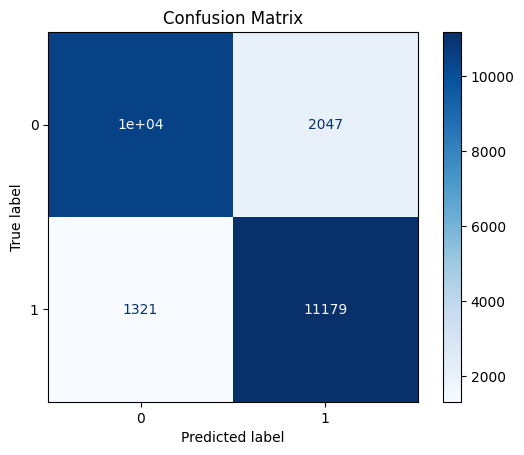

In [9]:
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [10]:
model.save("sentiment_analysis_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [11]:
word_index = imdb.get_word_index()

reverse_word_index = {
    value:key for (key,value) in word_index.items()
}

def decode_review(text):
    return " ".join(
        reverse_word_index.get(i-3, "?")
        for i in text
    )

sample = X_test[5]

print("Original Review:\n")
print(decode_review(sample))

prediction = model.predict(sample.reshape(1,-1))

print("\nPrediction:")

if prediction > 0.5:
    print("Positive Review ")
else:
    print("Negative Review ")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original Review:

? i'm absolutely disgusted this movie isn't being sold all who love this movie should email disney and increase the demand for it they'd eventually have to sell it then i'd buy copies for everybody i know everything and everybody in this movie did a good job and i haven't figured out why disney hasn't put this movie on dvd or on vhs in rental stores at least i haven't seen any copies this is a wicked good movie and should be seen by all the kids in the new generation don't get to see it and i think they should it should at least be put back on the channel this movie doesn't deserve a cheap ? it deserves the real thing i'm them now this movie will be on dvd ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Prediction:
Positive Review 


In [12]:
requirements = pd.DataFrame({

    "Requirement":[

        "Deep Learning Model",
        "TensorFlow",
        "Tokenization",
        "LSTM",
        "Training Curves",
        "Evaluation Metrics",
        "Confusion Matrix",
        "Model Saving",
        "Inference"

    ],

    "Status":[

        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"

    ]

})

requirements

,Requirement,Status
0,Deep Learning Model,Completed
1,TensorFlow,Completed
2,Tokenization,Completed
3,LSTM,Completed
4,Training Curves,Completed
5,Evaluation Metrics,Completed
6,Confusion Matrix,Completed
7,Model Saving,Completed
8,Inference,Completed
